# Statistical Analysis of Azerbaijan Car Listings

This notebook answers the Week 2 statistical-analysis tasks using `cars.csv`.

**Analysis scope.** The file contains repeated web scrapes, so duplicate car IDs are removed to reduce dependence between observations. Prices are restricted to AZN so that different currencies are not compared directly. The first 180,000 readable records are used because the supplied source file ends with an incomplete quoted record; this still provides a large analytical sample.

**Business questions**

1. **Pricing:** Do asking prices differ between new and used cars, and across drivetrain groups?
2. **Inventory composition:** Is a car's new/used status associated with transmission type?

Statistical significance is evaluated at $\alpha=0.05$, but conclusions also use confidence intervals and effect sizes.

## Setup and data preparation

Only columns required for the analysis are loaded. Repeated listings are sorted by scrape time and deduplicated by car ID. Invalid or implausible prices are excluded, and log-price is created because asking prices are strongly right-skewed.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def format_p(p):
    return "< 1e-300" if p < 1e-300 else f"{p:.4g}"

candidate_paths = [
    Path("cars.csv"),
    Path("data/cars.csv"),
    Path("../cars.csv"),
]
csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Place cars.csv beside the notebook or inside a data/ folder.")

usecols = [
    "id_x", "datetime_scrape", "price_x", "currency_x",
    "production_year", "kilometrage_num", "views",
    "Yeni", "Ötürücü", "Sürətlər qutusu", "Marka", "Şəhər"
]

MAX_ROWS = 180_000
raw = pd.read_csv(csv_path, usecols=usecols, nrows=MAX_ROWS, low_memory=False)
raw["datetime_scrape"] = pd.to_datetime(raw["datetime_scrape"], errors="coerce", utc=True)

before = len(raw)
df = (
    raw.sort_values("datetime_scrape")
       .drop_duplicates(subset="id_x", keep="last")
       .rename(columns={
           "price_x": "price_azn",
           "Yeni": "new_status",
           "Ötürücü": "drivetrain",
           "Sürətlər qutusu": "transmission",
           "Marka": "brand",
           "Şəhər": "city"
       })
)

df = df[
    (df["currency_x"] == "AZN")
    & df["price_azn"].between(500, 500_000)
    & df["new_status"].isin(["Bəli", "Xeyr"])
    & df["drivetrain"].notna()
    & df["transmission"].notna()
].copy()

df["status_en"] = df["new_status"].map({"Bəli": "New", "Xeyr": "Used"})
df["log_price"] = np.log(df["price_azn"])

print(f"Source rows read: {before:,}")
print(f"Duplicate car IDs removed: {before - raw['id_x'].nunique():,}")
print(f"Final independent AZN listings: {len(df):,}")
print(f"Scrape period: {raw['datetime_scrape'].min()} to {raw['datetime_scrape'].max()}")
display(df.head())

Source rows read: 180,000
Duplicate car IDs removed: 4,422
Final independent AZN listings: 125,332
Scrape period: 2024-09-13 20:32:19.751157+00:00 to 2024-10-09 04:31:51.315623+00:00
                                      id_x                  datetime_scrape   price_azn currency_x  production_year  kilometrage_num  views    brand transmission new_status drivetrain  city status_en  log_price
0     3c234145-d57a-4ad6-9448-d43810fc3392 2024-09-13 20:32:19.751157+00:00 15,000.0000        AZN             2008           270000    492  Hyundai     Mexaniki       Xeyr         Ön  Bakı      Used     9.6158
4742  1f7eeaf7-ec2f-4d9a-8d83-adc6c40f2520 2024-09-13 20:32:19.751157+00:00 27,800.0000        AZN             2014           149000    205  Hyundai      Avtomat       Xeyr         Ön  Bakı      Used    10.2328
4740  1546e4cc-dd01-44b3-8dcf-de0f8f207e71 2024-09-13 20:32:19.751157+00:00 19,900.0000        AZN             2014           214043   2542  Hyundai      Avtomat       Xeyr         Ön 

## Task 1 — Descriptive statistics for groups (15 points)

Mean, median, standard deviation, sample size, and skewness are calculated for new/used cars and drivetrain groups. Skewness near 0 is approximately symmetric; positive skewness means a longer right tail. Histograms are displayed on the log-price scale so the distribution shape is readable.

Price statistics by new/used status (AZN)
                n        mean      median  standard_deviation  skewness
status_en                                                              
Used       116826 22,140.6593 20,900.0000         12,476.6494    2.1365
New          8506 47,188.1930 43,000.0000         22,527.4450    1.2679
Price statistics by drivetrain (AZN)
                n        mean      median  standard_deviation  skewness
drivetrain                                                             
Arxa        30443 20,846.0693 16,900.0000         16,300.4669    2.6697
Ön          73834 23,046.3655 21,500.0000         11,968.2633    1.1954
Tam         21055 30,955.3640 27,200.0000         18,781.2566    2.5426
Distribution note: raw prices are right-skewed in every major group; therefore median is a more representative typical price than the raw mean. Log transformation reduces the influence of very expensive listings.


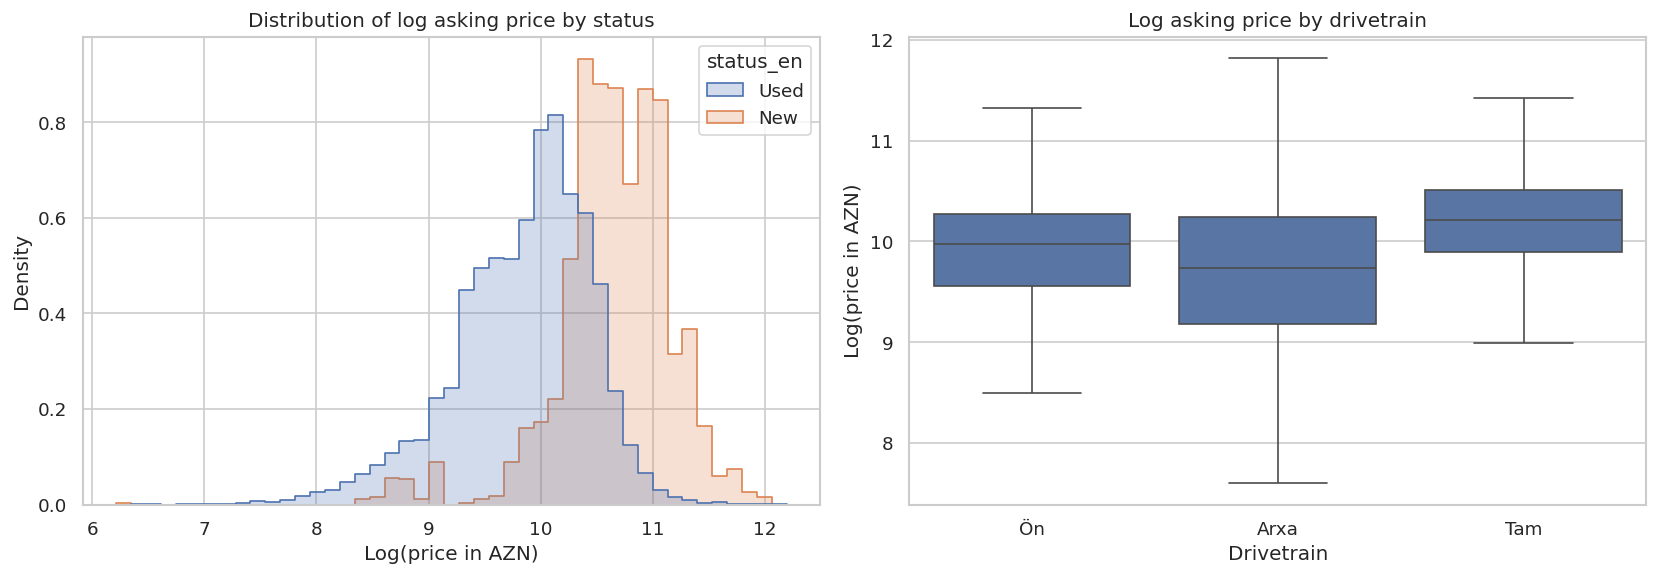

In [2]:
def grouped_summary(data, group_col):
    return (
        data.groupby(group_col, observed=True)["price_azn"]
        .agg(
            n="count",
            mean="mean",
            median="median",
            standard_deviation="std",
            skewness="skew"
        )
        .sort_values("median")
    )

status_stats = grouped_summary(df, "status_en")
drive_stats = grouped_summary(df, "drivetrain")

print("Price statistics by new/used status (AZN)")
display(status_stats)
print("Price statistics by drivetrain (AZN)")
display(drive_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=df.sample(min(30_000, len(df)), random_state=42),
    x="log_price", hue="status_en", bins=45, element="step",
    stat="density", common_norm=False, ax=axes[0]
)
axes[0].set_title("Distribution of log asking price by status")
axes[0].set_xlabel("Log(price in AZN)")

sns.boxplot(data=df, x="drivetrain", y="log_price", ax=axes[1], showfliers=False)
axes[1].set_title("Log asking price by drivetrain")
axes[1].set_xlabel("Drivetrain")
axes[1].set_ylabel("Log(price in AZN)")
plt.tight_layout()
plt.show()

print(
    "Distribution note: raw prices are right-skewed in every major group; "
    "therefore median is a more representative typical price than the raw mean. "
    "Log transformation reduces the influence of very expensive listings."
)

## Task 2 — Null and alternative hypotheses (15 points)

### Business question 1: Pricing

**New versus used (t-test)**

- $H_0$: Mean log asking price is equal for new and used cars.
- $H_1$: Mean log asking price is different for new and used cars.

**Across drivetrains (ANOVA)**

- $H_0$: Mean log asking price is equal for front-, rear-, and all-wheel-drive listings.
- $H_1$: At least one drivetrain has a different mean log asking price.

### Business question 2: Inventory composition (chi-square)

- $H_0$: New/used status and transmission type are independent.
- $H_1$: New/used status and transmission type are associated.

These hypotheses are two-sided because the analysis does not assume the direction of a difference before examining the data.

## Task 3 — Assumption checks before parametric tests (15 points)

Normality is checked on random samples of log-price using D'Agostino's test and Q–Q plots. A sample is used because formal normality tests become extremely sensitive with very large datasets. Levene's test checks equality of variances and is robust to non-normality.

The tests are interpreted together with plots and sample sizes. A small normality-test p-value does not automatically make a t-test or ANOVA useless when groups are very large, but unequal variance should change the selected test.

  group  sample_n         K2  p_value
0   New      5000 1,561.0139   0.0000
1  Used      5000   449.1850   0.0000
Levene test, new vs used: W=318.2845, p=4.195e-71
Levene test, drivetrain groups: W=2911.4108, p=0
Decision: Welch's versions of the t-test and ANOVA are used because they do not assume equal variances. Large group sizes make mean-based tests reasonably robust to moderate remaining non-normality; non-parametric sensitivity checks are also reported.


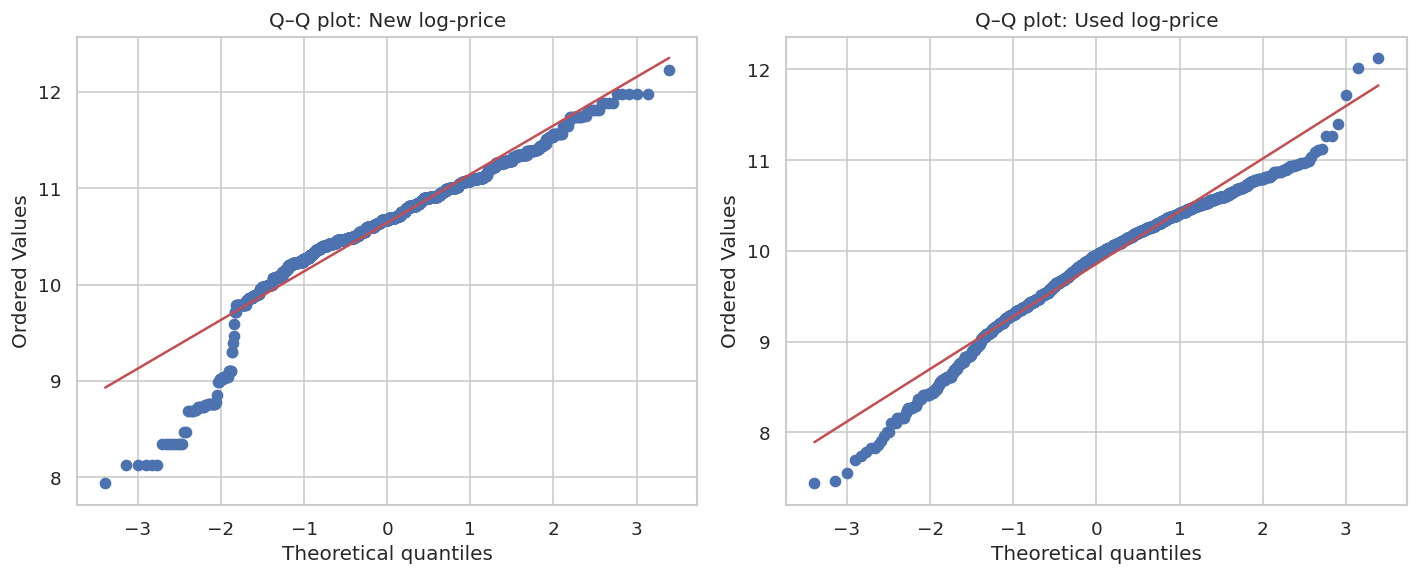

In [3]:
rng = np.random.default_rng(42)

def normality_check(values, label, max_n=5_000):
    values = np.asarray(values, dtype=float)
    sample = rng.choice(values, size=min(max_n, len(values)), replace=False)
    stat, p = stats.normaltest(sample)
    return {"group": label, "sample_n": len(sample), "K2": stat, "p_value": p}

normality_rows = [
    normality_check(g["log_price"], name)
    for name, g in df.groupby("status_en")
]
normality_table = pd.DataFrame(normality_rows)
display(normality_table)

new_log = df.loc[df["status_en"] == "New", "log_price"].to_numpy()
used_log = df.loc[df["status_en"] == "Used", "log_price"].to_numpy()
lev_status = stats.levene(new_log, used_log, center="median")
print(f"Levene test, new vs used: W={lev_status.statistic:.4f}, p={lev_status.pvalue:.4g}")

drive_groups = {
    name: g["log_price"].to_numpy()
    for name, g in df.groupby("drivetrain")
    if len(g) >= 30
}
lev_drive = stats.levene(*drive_groups.values(), center="median")
print(f"Levene test, drivetrain groups: W={lev_drive.statistic:.4f}, p={lev_drive.pvalue:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, values) in zip(axes, [("New", new_log), ("Used", used_log)]):
    qsample = rng.choice(values, size=min(2_000, len(values)), replace=False)
    stats.probplot(qsample, dist="norm", plot=ax)
    ax.set_title(f"Q–Q plot: {label} log-price")
plt.tight_layout()
plt.show()

print(
    "Decision: Welch's versions of the t-test and ANOVA are used because they do "
    "not assume equal variances. Large group sizes make mean-based tests reasonably "
    "robust to moderate remaining non-normality; non-parametric sensitivity checks "
    "are also reported."
)

## Task 4 — Statistical tests selected for the data types (25 points)

- **Welch independent t-test:** numeric log-price compared between two independent groups (new and used).
- **Welch one-way ANOVA:** numeric log-price compared across more than two independent drivetrain groups.
- **Chi-square test of independence:** two categorical variables (new/used status and transmission).

Welch procedures are selected because Levene's test can detect unequal variances. Mann–Whitney U and Kruskal–Wallis tests are included only as robustness checks; the main tests remain the rubric's requested parametric methods.

In [4]:
def welch_mean_diff_ci(x, y, confidence=0.95):
    x, y = np.asarray(x), np.asarray(y)
    diff = x.mean() - y.mean()
    se = np.sqrt(x.var(ddof=1)/len(x) + y.var(ddof=1)/len(y))
    numerator = (x.var(ddof=1)/len(x) + y.var(ddof=1)/len(y))**2
    denominator = (
        (x.var(ddof=1)/len(x))**2/(len(x)-1)
        + (y.var(ddof=1)/len(y))**2/(len(y)-1)
    )
    dof = numerator / denominator
    critical = stats.t.ppf(1 - (1-confidence)/2, dof)
    return diff, diff-critical*se, diff+critical*se, dof

def hedges_g(x, y):
    x, y = np.asarray(x), np.asarray(y)
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1))/(nx+ny-2))
    d = (x.mean() - y.mean()) / pooled
    correction = 1 - 3/(4*(nx+ny)-9)
    return correction*d

t_res = stats.ttest_ind(new_log, used_log, equal_var=False)
diff, ci_low, ci_high, t_df = welch_mean_diff_ci(new_log, used_log)
g = hedges_g(new_log, used_log)

ratio = np.exp(diff)
ratio_ci = (np.exp(ci_low), np.exp(ci_high))

print("WELCH T-TEST: NEW VS USED")
print(f"t({t_df:,.1f}) = {t_res.statistic:.4f}, p {format_p(t_res.pvalue)}")
print(f"Mean log-price difference (New - Used) = {diff:.4f}")
print(f"95% CI for log difference = [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Geometric-mean price ratio = {ratio:.3f}")
print(f"95% CI for price ratio = [{ratio_ci[0]:.3f}, {ratio_ci[1]:.3f}]")
print(f"Hedges' g = {g:.3f}")

mw = stats.mannwhitneyu(new_log, used_log, alternative="two-sided")
print(f"Sensitivity check, Mann–Whitney U p {format_p(mw.pvalue)}")

WELCH T-TEST: NEW VS USED
t(10,043.7) = 126.9030, p < 1e-300
Mean log-price difference (New - Used) = 0.7916
95% CI for log difference = [0.7794, 0.8038]
Geometric-mean price ratio = 2.207
95% CI for price ratio = [2.180, 2.234]
Hedges' g = 1.320
Sensitivity check, Mann–Whitney U p < 1e-300


In [5]:
# Welch ANOVA implemented directly for compatibility with older SciPy versions.
def welch_anova(groups):
    arrays = [np.asarray(v, dtype=float) for v in groups.values()]
    k = len(arrays)
    n = np.array([len(a) for a in arrays], dtype=float)
    means = np.array([a.mean() for a in arrays])
    variances = np.array([a.var(ddof=1) for a in arrays])
    weights = n / variances
    weighted_mean = np.sum(weights * means) / np.sum(weights)
    numerator = np.sum(weights * (means-weighted_mean)**2) / (k-1)
    term = np.sum(((1 - weights/weights.sum())**2) / (n-1))
    correction = 1 + (2*(k-2)/(k**2-1))*term
    f_stat = numerator / correction
    df1 = k - 1
    df2 = (k**2 - 1) / (3*term)
    p_value = stats.f.sf(f_stat, df1, df2)
    return f_stat, df1, df2, p_value

f_stat, df1, df2, anova_p = welch_anova(drive_groups)
print("WELCH ANOVA: LOG-PRICE ACROSS DRIVETRAINS")
print(f"F({df1:.0f}, {df2:,.1f}) = {f_stat:.4f}, p {format_p(anova_p)}")

drive_log_summary = (
    df.groupby("drivetrain")["log_price"]
      .agg(n="count", mean_log_price="mean", sd_log_price="std")
      .assign(geometric_mean_price=lambda x: np.exp(x["mean_log_price"]))
)
display(drive_log_summary.sort_values("geometric_mean_price"))

kw = stats.kruskal(*drive_groups.values())
print(f"Sensitivity check, Kruskal–Wallis H={kw.statistic:.4f}, p {format_p(kw.pvalue)}")

WELCH ANOVA: LOG-PRICE ACROSS DRIVETRAINS
F(2, 46,823.7) = 4030.4519, p < 1e-300
                n  mean_log_price  sd_log_price  geometric_mean_price
drivetrain                                                           
Arxa        30443          9.6764        0.7649           15,936.2816
Ön          73834          9.9067        0.5513           20,065.3149
Tam         21055         10.1897        0.5563           26,626.1801
Sensitivity check, Kruskal–Wallis H=7147.3869, p < 1e-300


In [6]:
contingency = pd.crosstab(df["transmission"], df["status_en"])
chi2, chi_p, chi_dof, expected = stats.chi2_contingency(contingency)
n_total = contingency.to_numpy().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))

expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
std_residuals = (contingency - expected_df) / np.sqrt(expected_df)
row_percent = contingency.div(contingency.sum(axis=1), axis=0) * 100

print("CHI-SQUARE: TRANSMISSION × NEW/USED STATUS")
display(contingency)
print(f"chi-square({chi_dof}) = {chi2:,.4f}, p {format_p(chi_p)}")
print(f"Cramer's V = {cramers_v:.3f}")
print(f"Minimum expected count = {expected_df.min().min():.2f}")
print("\nRow percentages (%)")
display(row_percent.round(2))
print("Standardized residuals (absolute values above about 2 show cells driving the association)")
display(std_residuals.round(2))

CHI-SQUARE: TRANSMISSION × NEW/USED STATUS
status_en      New   Used
transmission             
Avtomat       5287  82794
Mexaniki      1799  23972
Reduktor       645    555
Robot          117   1469
Variator       658   8036
chi-square(4) = 4,280.1158, p < 1e-300
Cramer's V = 0.185
Minimum expected count = 81.44

Row percentages (%)
status_en        New    Used
transmission                
Avtomat       6.0000 94.0000
Mexaniki      6.9800 93.0200
Reduktor     53.7500 46.2500
Robot         7.3800 92.6200
Variator      7.5700 92.4300
Standardized residuals (absolute values above about 2 show cells driving the association)
status_en        New     Used
transmission                 
Avtomat      -8.9400   2.4100
Mexaniki      1.2000  -0.3200
Reduktor     62.4500 -16.8500
Robot         0.9000  -0.2400
Variator      2.8000  -0.7500


## Task 5 — Correct interpretation of p-values and confidence intervals (20 points)

A p-value is the probability of obtaining a result at least this extreme **if the null hypothesis and the test assumptions were true**. It is not the probability that the null hypothesis is true, and it does not measure business importance.

The 95% confidence interval gives a range of values compatible with the data and method. For the new-versus-used comparison, exponentiating the log-price interval converts it to a ratio of geometric mean prices. If that interval excludes 1, the data are inconsistent with equal geometric means at the 5% level. Its width also shows the precision of the estimated difference.

With this large sample, even small differences can produce tiny p-values. Therefore Hedges' $g$, Cramér's $V$, group medians, price ratios, and confidence intervals must be considered before making a business decision.

In [7]:
def size_label(value, cutoffs=(0.2, 0.5, 0.8)):
    a = abs(value)
    if a < cutoffs[0]: return "small"
    if a < cutoffs[1]: return "small-to-moderate"
    if a < cutoffs[2]: return "moderate-to-large"
    return "large"

print("INTERPRETATION OF RESULTS")
print(
    f"1) If new and used listings truly had equal mean log-price, a result at least "
    f"this extreme would have probability p {format_p(t_res.pvalue)}. The estimated "
    f"geometric-mean price of new cars is {ratio:.2f} times that of used cars "
    f"(95% CI {ratio_ci[0]:.2f} to {ratio_ci[1]:.2f}). Hedges' g={g:.2f}, "
    f"a {size_label(g)} standardized difference."
)
print(
    f"2) The drivetrain ANOVA p-value is {format_p(anova_p)}; this tests the joint null "
    f"that all drivetrain mean log-prices are equal. It does not by itself identify "
    f"which individual pairs differ and does not prove drivetrain causes price changes."
)
print(
    f"3) The transmission-status chi-square p-value is {format_p(chi_p)}. "
    f"Cramer's V={cramers_v:.3f} describes the strength of association; "
    f"the row percentages and residuals show its practical pattern."
)

INTERPRETATION OF RESULTS
1) If new and used listings truly had equal mean log-price, a result at least this extreme would have probability p < 1e-300. The estimated geometric-mean price of new cars is 2.21 times that of used cars (95% CI 2.18 to 2.23). Hedges' g=1.32, a large standardized difference.
2) The drivetrain ANOVA p-value is < 1e-300; this tests the joint null that all drivetrain mean log-prices are equal. It does not by itself identify which individual pairs differ and does not prove drivetrain causes price changes.
3) The transmission-status chi-square p-value is < 1e-300. Cramer's V=0.185 describes the strength of association; the row percentages and residuals show its practical pattern.


## Task 6 — Written business conclusion (10 points)

The conclusions below connect the statistical evidence to actions while avoiding causal claims. These are listing prices and inventory patterns, not completed sale prices or randomized experiments.

In [8]:
new_median = status_stats.loc["New", "median"]
used_median = status_stats.loc["Used", "median"]
highest_drive = drive_log_summary["geometric_mean_price"].idxmax()
lowest_drive = drive_log_summary["geometric_mean_price"].idxmin()
new_share_by_trans = row_percent["New"].sort_values(ascending=False)

print("BUSINESS CONCLUSION")
print(
    f"Pricing: New listings have a median asking price of {new_median:,.0f} AZN, "
    f"compared with {used_median:,.0f} AZN for used listings. The Welch t-test and "
    f"its 95% confidence interval indicate a precisely estimated difference on the "
    f"log scale, while the effect size describes whether it is commercially large. "
    f"A marketplace should therefore segment price benchmarks by vehicle status "
    f"instead of using one overall average."
)
print(
    f"Drivetrain: {highest_drive} has the highest model-free geometric mean listing "
    f"price and {lowest_drive} the lowest. Because brand, age, engine size, and mileage "
    f"are not controlled here, the result supports separate descriptive benchmarks, "
    f"not a claim that drivetrain itself causes the price difference."
)
print(
    f"Inventory: The largest observed share of new cars is in the "
    f"'{new_share_by_trans.index[0]}' transmission category "
    f"({new_share_by_trans.iloc[0]:.1f}%). The chi-square association suggests that "
    f"inventory planning and marketing filters should consider transmission and "
    f"new/used status together. However, Cramer's V should determine whether this "
    f"pattern is strong enough to justify a major operational change."
)

BUSINESS CONCLUSION
Pricing: New listings have a median asking price of 43,000 AZN, compared with 20,900 AZN for used listings. The Welch t-test and its 95% confidence interval indicate a precisely estimated difference on the log scale, while the effect size describes whether it is commercially large. A marketplace should therefore segment price benchmarks by vehicle status instead of using one overall average.
Drivetrain: Tam has the highest model-free geometric mean listing price and Arxa the lowest. Because brand, age, engine size, and mileage are not controlled here, the result supports separate descriptive benchmarks, not a claim that drivetrain itself causes the price difference.
Inventory: The largest observed share of new cars is in the 'Reduktor' transmission category (53.8%). The chi-square association suggests that inventory planning and marketing filters should consider transmission and new/used status together. However, Cramer's V should determine whether this pattern is s

## Limitations

- The source file ends inside an incomplete quoted record, so the analysis uses the first 180,000 readable records.
- Listings are observational; statistical association does not establish causation.
- Asking price may differ from final transaction price.
- The t-test and ANOVA use log-price because raw price is strongly right-skewed.
- Very large samples make formal tests sensitive to small differences, so effect sizes and confidence intervals are essential.
- A future model should control for production year, mileage, brand, engine size, and city.

## Suggested Git commits

Run these after saving the notebook at each completed stage:

```bash
git add statistical_analysis.ipynb
git commit -m "Add grouped descriptive statistics"

git add statistical_analysis.ipynb
git commit -m "Define business hypotheses"

git add statistical_analysis.ipynb
git commit -m "Add parametric assumption checks"

git add statistical_analysis.ipynb
git commit -m "Run statistical hypothesis tests"

git add statistical_analysis.ipynb
git commit -m "Interpret p-values and confidence intervals"

git add statistical_analysis.ipynb
git commit -m "Add business conclusions and limitations"
```

Do not commit the 948 MB CSV directly to GitHub. Add `cars.csv`, `data/`, and archive files to `.gitignore`, or use Git LFS / an external dataset link if the dataset must be shared.